In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("netflix_titles.csv")

## Basic Information  

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8800 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
df.shape

(8807, 12)

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [10]:
df.duplicated()                     

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Length: 8807, dtype: bool

## Summary

###### 1. We have Dataframe of 12 Coloumn and 8807 Rows
###### 2. The Dataset donot contain any Duplicate Values
###### 3. The Dataset have missing rating which needs to be set as "not rated"
###### 4. The date_added column format needs to be changed in datetime format
###### 5. The Duration column has data in two datatype in integer and varchar so this needs to be split into two coloumns
###### 6. The listed_in column has comma separated values which needs to be handled and casted into different categories
###### 7. The coloumn such as director,cast and country have missing value 


### Working with missing data

In [11]:
df['rating'] = df['rating'].fillna('Not Rated')
df['director']=df['director'].fillna('Not mentioned')
df['cast']=df['cast'].fillna('Not mentioned')
df['country']=df['country'].fillna('Not mentioned')
df['country']=df['country'].fillna('Not mentioned')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not mentioned,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Not mentioned,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not mentioned,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Not mentioned,Not mentioned,Not mentioned,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Not mentioned,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [12]:
df = df.dropna(subset=['date_added'])
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not mentioned,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Not mentioned,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not mentioned,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Not mentioned,Not mentioned,Not mentioned,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Not mentioned,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Converting dates into date time format

In [13]:
df['date_added']=df['date_added'].astype(str)

In [14]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not mentioned,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,TV Show,Blood & Water,Not mentioned,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not mentioned,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September
3,s4,TV Show,Jailbirds New Orleans,Not mentioned,Not mentioned,Not mentioned,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September
4,s5,TV Show,Kota Factory,Not mentioned,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int64         
 8   rating        8797 non-null   object        
 9   duration      8797 non-null   object        
 10  listed_in     8797 non-null   object        
 11  description   8797 non-null   object        
 12  year_added    8797 non-null   int32         
 13  month_added   8797 non-null   object        
dtypes: datetime64[ns](1), int32(1), int64(1), object(11)
memory usage: 996.5+ KB


### Splitting listed_in into list

In [17]:
df['listed_in'] = df['listed_in'].str.split(', ')
df = df.explode('listed_in').reset_index(drop = True)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not mentioned,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,TV Show,Blood & Water,Not mentioned,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,September
2,s2,TV Show,Blood & Water,Not mentioned,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021,September
3,s2,TV Show,Blood & Water,Not mentioned,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021,September
4,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not mentioned,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021,September


### Converting listed_in into category datatype

In [18]:
df["listed_in"]=df["listed_in"].astype('category')
df['listed_in'].dtype

CategoricalDtype(categories=['Action & Adventure', 'Anime Features', 'Anime Series',
                  'British TV Shows', 'Children & Family Movies',
                  'Classic & Cult TV', 'Classic Movies', 'Comedies',
                  'Crime TV Shows', 'Cult Movies', 'Documentaries',
                  'Docuseries', 'Dramas', 'Faith & Spirituality',
                  'Horror Movies', 'Independent Movies',
                  'International Movies', 'International TV Shows', 'Kids' TV',
                  'Korean TV Shows', 'LGBTQ Movies', 'Movies',
                  'Music & Musicals', 'Reality TV', 'Romantic Movies',
                  'Romantic TV Shows', 'Sci-Fi & Fantasy',
                  'Science & Nature TV', 'Spanish-Language TV Shows',
                  'Sports Movies', 'Stand-Up Comedy',
                  'Stand-Up Comedy & Talk Shows', 'TV Action & Adventure',
                  'TV Comedies', 'TV Dramas', 'TV Horror', 'TV Mysteries',
                  'TV Sci-Fi & Fantasy', '

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19303 entries, 0 to 19302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       19303 non-null  object        
 1   type          19303 non-null  object        
 2   title         19303 non-null  object        
 3   director      19303 non-null  object        
 4   cast          19303 non-null  object        
 5   country       19303 non-null  object        
 6   date_added    19303 non-null  datetime64[ns]
 7   release_year  19303 non-null  int64         
 8   rating        19303 non-null  object        
 9   duration      19303 non-null  object        
 10  listed_in     19303 non-null  category      
 11  description   19303 non-null  object        
 12  year_added    19303 non-null  int32         
 13  month_added   19303 non-null  object        
dtypes: category(1), datetime64[ns](1), int32(1), int64(1), object(10)
memory usage: 1.9+ M

### Spliting duration column into two column seasons and duration_mins

In [20]:
duration_parts = df['duration'].str.split(' ', expand=True)
df['seasons'] = np.where(df['type'] == 'TV Show', df['duration'], np.nan)
df['duration_mins'] = np.where(df['type'] == 'Movie', duration_parts[0].astype(float), np.nan)
df = df.drop(columns=['duration'])

In [21]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,year_added,month_added,seasons,duration_mins
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not mentioned,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",2021,September,NaN,90.0
1,s2,TV Show,Blood & Water,Not mentioned,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,September,2 Seasons,NaN
2,s2,TV Show,Blood & Water,Not mentioned,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021,September,2 Seasons,NaN
3,s2,TV Show,Blood & Water,Not mentioned,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021,September,2 Seasons,NaN
4,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not mentioned,2021-09-24,2021,TV-MA,Crime TV Shows,To protect his family from a powerful drug lor...,2021,September,1 Season,NaN


# Data Visualization

In [22]:
plt.style.use("ggplot")

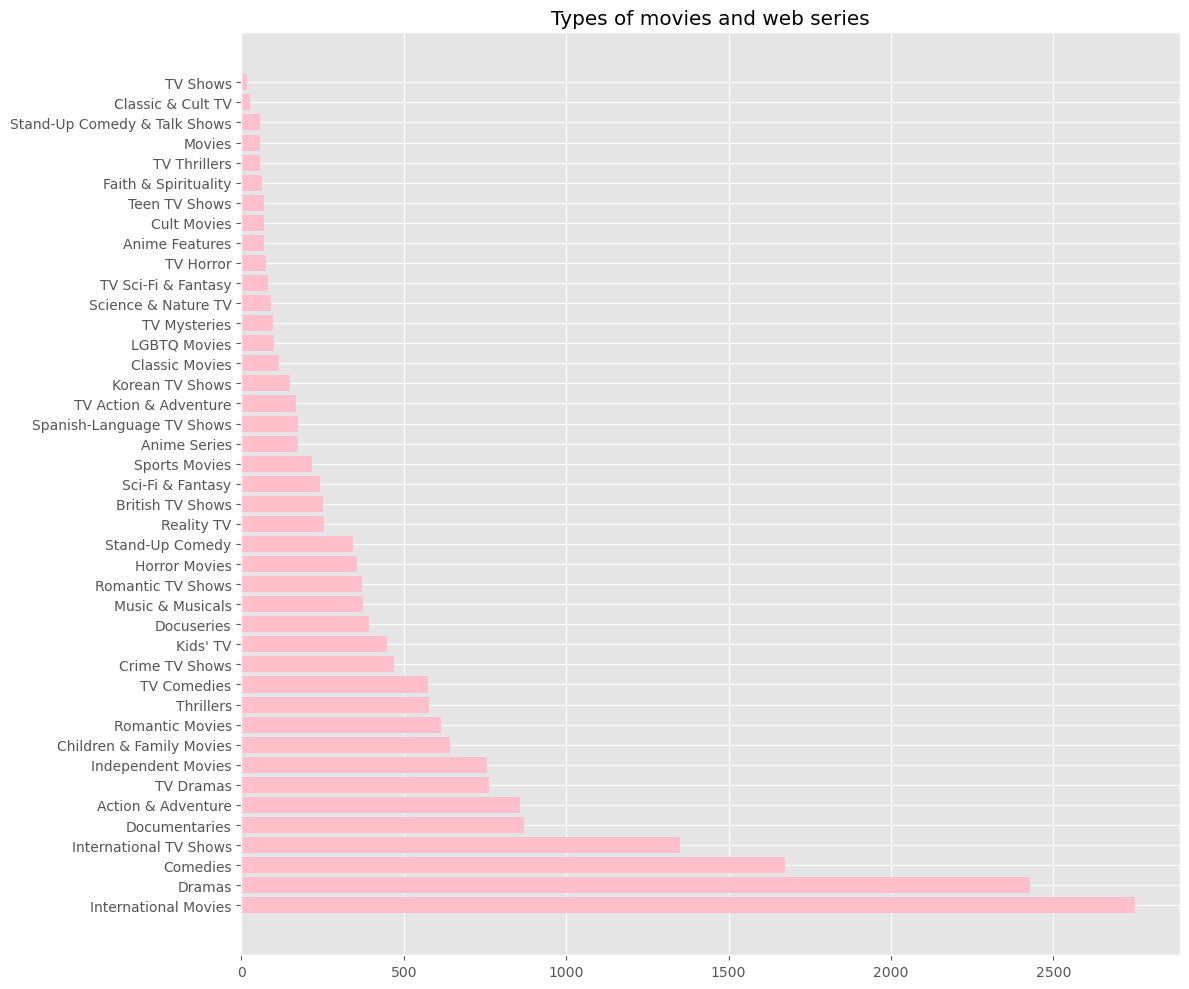

In [23]:
counts = df['listed_in'].value_counts()
plt.figure(figsize=(12, 10))
plt.barh(counts.index, counts.values, color="pink")
plt.title("Types of movies and web series")
plt.tight_layout()
plt.show()

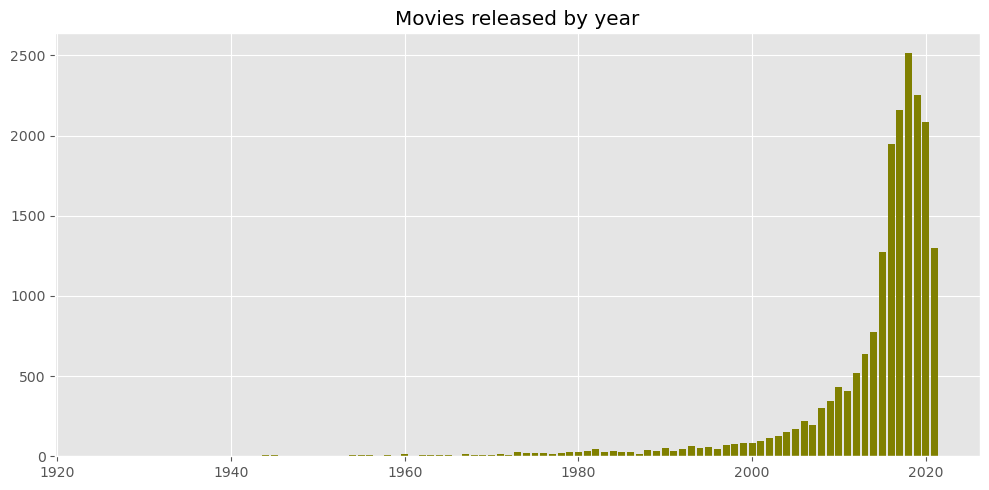

In [24]:
counts = df['release_year'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(counts.index, counts.values, color="olive")
plt.title("Movies released by year")
plt.tight_layout()
plt.show()

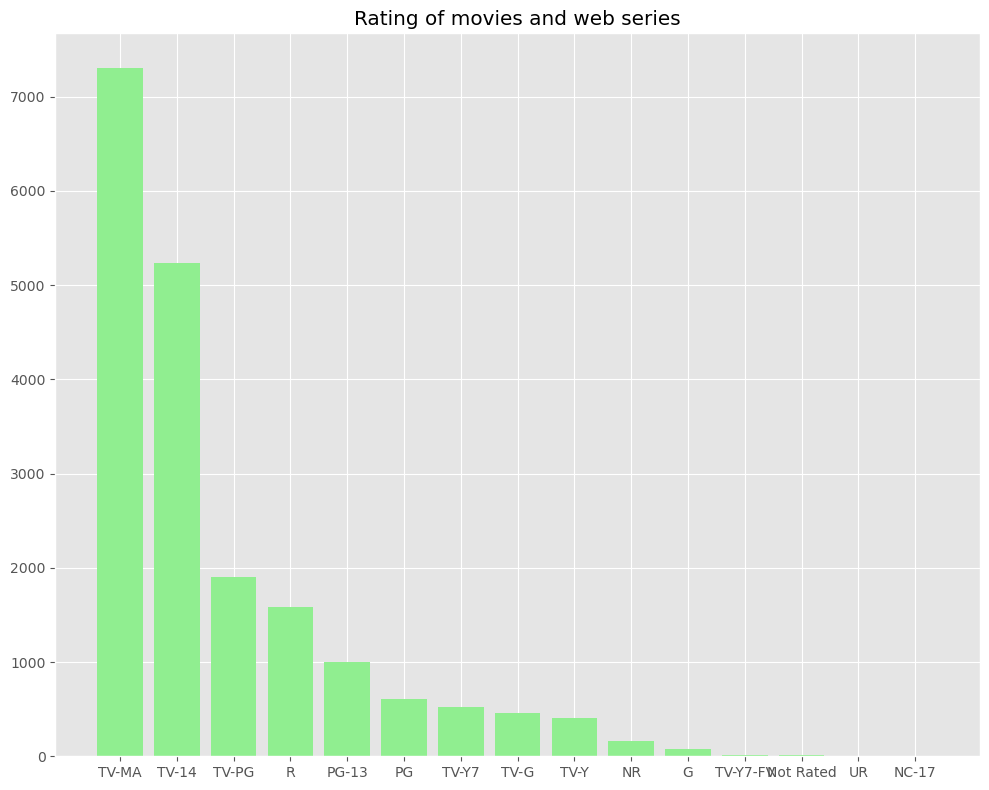

In [32]:
counts = df['rating'].value_counts()
plt.figure(figsize=(10, 8))
plt.bar(counts.index, counts.values, color="lightgreen")
plt.title("Rating of movies and web series")
plt.tight_layout()
plt.show()

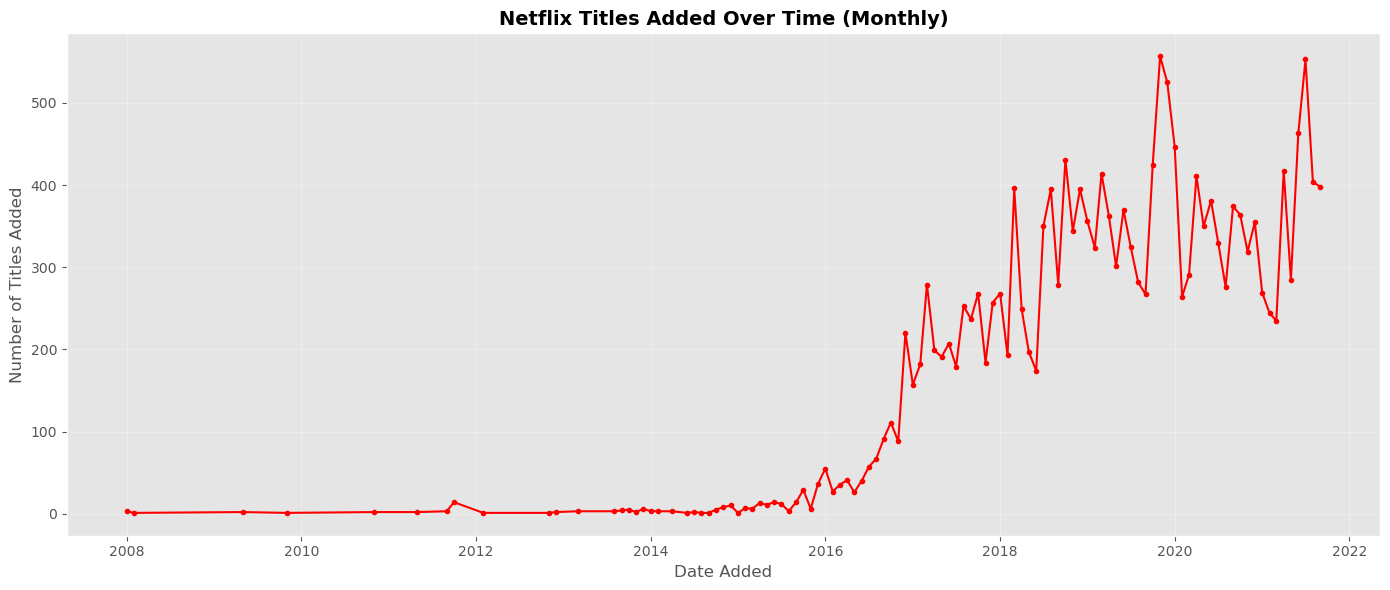

In [34]:
# Group by year and month to count titles added
monthly_counts = df.groupby(['year_added', 'month_added']).size().reset_index(name='count')

# Creating proper datetime for plotting (here day=1 for all the  month)
monthly_counts['date'] = pd.to_datetime(
    monthly_counts['year_added'].astype('Int64').astype(str) + '-' + monthly_counts['month_added'],
    format='%Y-%B',
    errors='coerce'
)
monthly_counts = monthly_counts.dropna(subset=['date']).sort_values('date')

plt.figure(figsize=(14, 6))
plt.plot(monthly_counts['date'], monthly_counts['count'], marker='o', markersize=3, linewidth=1.5, color='red')
plt.title('Netflix Titles Added Over Time (Monthly)', fontsize=14, fontweight='bold')
plt.xlabel('Date Added')
plt.ylabel('Number of Titles Added')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

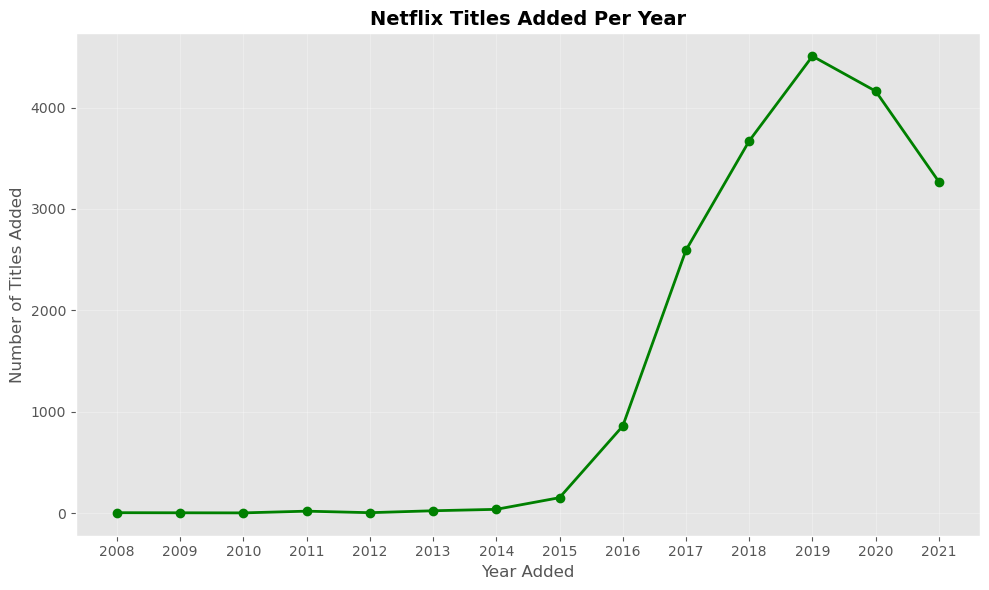

In [33]:
yearly_counts = df.groupby('year_added').size().reset_index(name='count')
yearly_counts = yearly_counts.dropna(subset=['year_added']).sort_values('year_added')

plt.figure(figsize=(10, 6))
plt.plot(yearly_counts['year_added'], yearly_counts['count'], marker='o', linewidth=2, color='green')
plt.title('Netflix Titles Added Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.grid(alpha=0.3)
plt.xticks(yearly_counts['year_added'].astype(int))
plt.tight_layout()
plt.show()

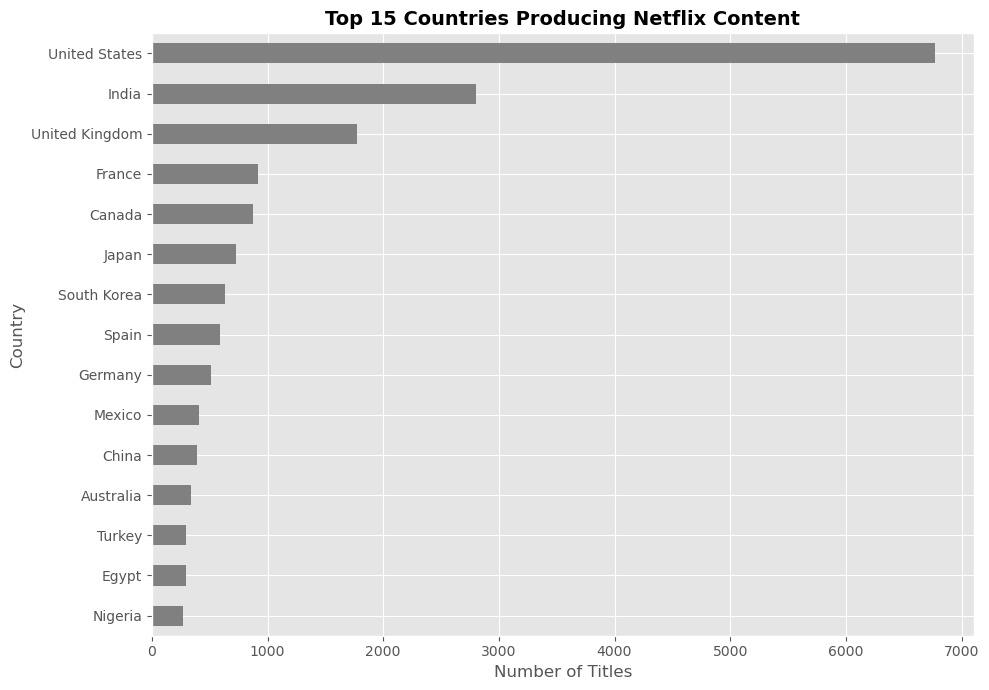

In [38]:
# Split multi-country entries and count each country separately
countries = df['country'].dropna()
countries = countries[countries.str.strip() != 'Not mentioned']
country_counts = countries.str.split(', ').explode().str.strip().value_counts().head(15)

plt.figure(figsize=(10, 7))
country_counts.sort_values().plot(kind='barh', color='grey')

plt.title('Top 15 Countries Producing Netflix Content', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

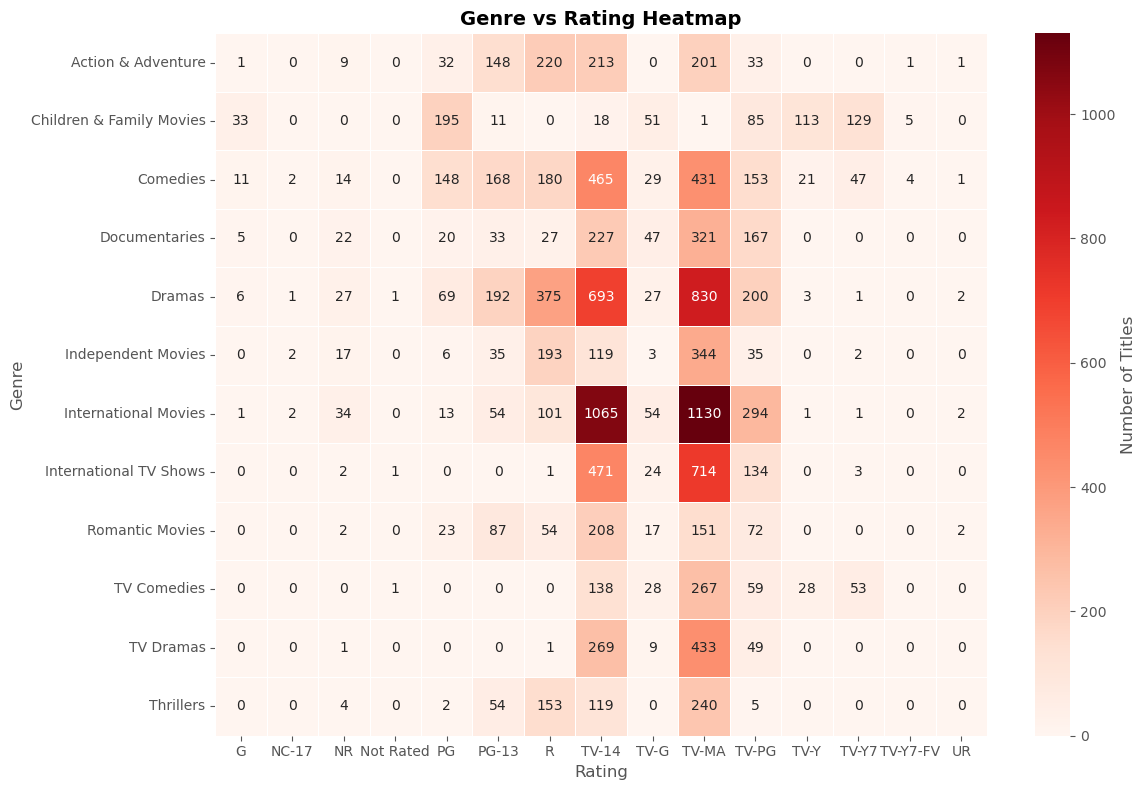

In [52]:
# Clean and explode genres (listed_in is comma-separated, like country)
genre_df = df[['listed_in', 'rating']].dropna()
genre_df = genre_df.assign(genre=genre_df['listed_in'].str.split(', ')).explode('genre')
genre_df['genre'] = genre_df['genre'].str.strip()

top_genres = genre_df['genre'].value_counts().head(12).index
genre_df = genre_df[genre_df['genre'].isin(top_genres)]

# Build genre x rating count matrix
heatmap_data = pd.crosstab(genre_df['genre'], genre_df['rating'])

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt='d', linewidths=0.5, cbar_kws={'label': 'Number of Titles'})
plt.title('Genre vs Rating Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

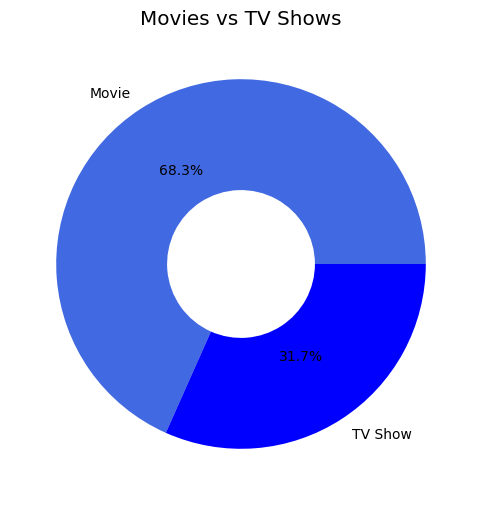

In [48]:
type_counts = df['type'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['royalblue', 'blue'], wedgeprops=dict(width=0.6))
plt.title('Movies vs TV Shows')
plt.show()

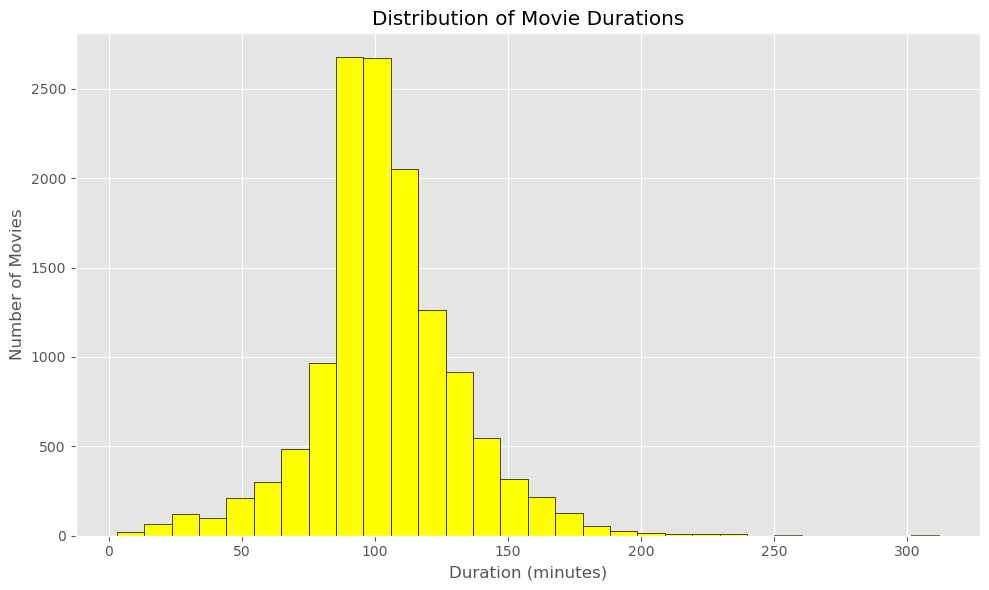

In [51]:
movie_durations = df[df['type'] == 'Movie']['duration_mins'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(movie_durations, bins=30, color='yellow', edgecolor='black')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

# Conclusion

This EDA analyzed the Netflix titles dataset (~8,800 entries), covering data cleaning (splitting duration into seasons/duration_mins, Filling missing values, removing some values) and did nine visualizations with proper analysis of them.

# Key findings:

1. Total movie are 68.3% and Tv shows are 31.7%
2. Movie with duration 100 min are around 2750
3. Rating of International movie having rating TV-14 and TV-MA are 1065 and 1130 respectively.
4. US has produced the hightest netflix movies and shows that is around 6750, followed by India around 2800 and then Uk around 1800
5. In 2019 year highest neflix production is tehre that is around 4500 
6. Movies and TV show have highest number of rating of TV-MA
7. Movies make up 68.3% of the catalog, while TV Shows make up 31.7%.
8. Movie durations peak around the 90–100 minute range, the most common runtime among all movies.
9. Among International Movies, 1,130 titles are rated TV-MA and 1,065 are rated TV-14, showing a lean toward mature content in this genre.
10. The United States produced the most Netflix content (~6,750 titles), followed by India (~2,800) and the UK (~1,800).
11. 2019 saw the highest number of titles added (~4,500) — though this may partly reflect incomplete data for later years rather than an actual decline in content additions.
TV-MA is the most common rating overall, across both Movies and TV Shows, indicating Netflix's catalog skews toward mature audiences.
# Limitations:

Here country, cast, and director had many missing/"Not mentioned" values, which were not counted dudirng the visulization.
The dataset only reflects Netflix's catalog as of its snapshot date, not real-time content or viewership data.

# Possible next steps:

Here external should needs to be added for better outcome and ananlysis of the data(i.e IMDB Rating)